In [1]:
%load_ext autoreload
%autoreload 0
%matplotlib inline

In [2]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing


In [3]:
from omicsone_streamlit.utils.diff import compare_two_groups
from omicsone_streamlit.plots.volcano import plot_volcano

In [6]:
DATA_DIR = Path(r"F:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\20260402_msfragger_cptac_protein_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True True


In [9]:
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [10]:
meta = pd.read_csv(meta_path)
sample_id_col = "common_ID"
meta_normal = meta[meta["Tissuetype"] == "normal"]
meta_tumor = meta[meta["Tissuetype"] == "tumor"]
purity_map = dict(zip(meta[sample_id_col], meta["FirstCategory"]))
stage_map = dict(zip(meta[sample_id_col], meta["stage"]))
gleason_map = dict(zip(meta[sample_id_col], meta["Grade_Group"]))
tumors_included = meta_tumor[sample_id_col].tolist()
normals = meta_normal[sample_id_col].tolist()

In [12]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"prostate_CPTAC_prot_TMT_abundance_gene_MD",i.stem, re.IGNORECASE) \
    and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
protein_header_cols = ["geneSymbol","Index"]
data = pd.read_csv(data_path,sep="\t").set_index(protein_header_cols)
data_nomiss = data.dropna()

In [13]:
tumors_included = [i for i in tumors_included if i in data_nomiss.columns]
normals = [i for i in normals if i in data_nomiss.columns]
print(f"Number of tumors included: {len(tumors_included)}")
print(f"Number of normals included: {len(normals)}")

Number of tumors included: 134
Number of normals included: 33


In [14]:
omics1_diff = compare_two_groups(data, tumors_included, normals, 
                                method="Wilcoxon(Unpaired)",
                                max_miss_ratio_global=0.5, 
                                max_miss_ratio_group=0.5,
                                fdr_cutoff=0.01, 
                                log2fc_cutoff=1)

10978it [00:08, 1313.01it/s]


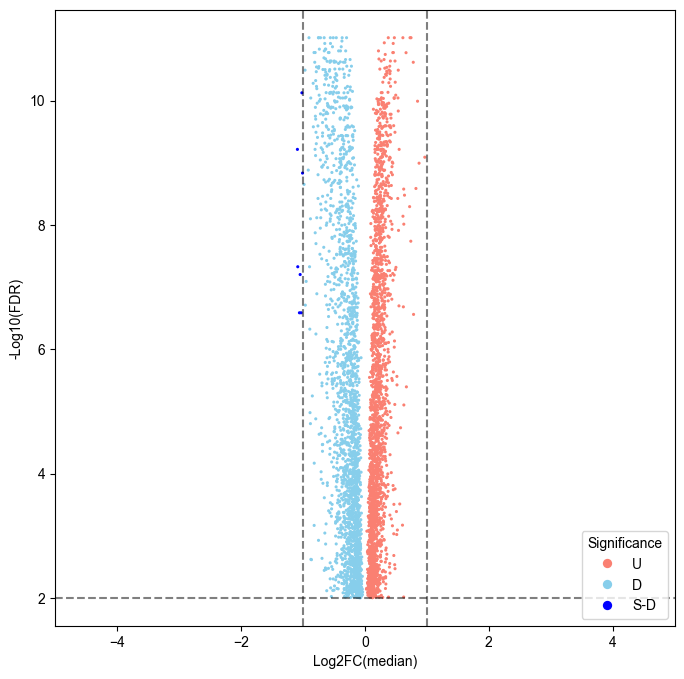

In [15]:
fig = plot_volcano(omics1_diff,xlim=(-5,5))

In [24]:
high_grade_tumors = []
low_grade_tumors = []
for i in gleason_map:
    if re.search("GG[1]", str(gleason_map[i])):
        low_grade_tumors.append(i)
    elif re.search("GG[4]", str(gleason_map[i])):
        high_grade_tumors.append(i)

In [25]:
print(len(high_grade_tumors), len(low_grade_tumors))

47 10


In [26]:


diff2 = compare_two_groups(data, high_grade_tumors, low_grade_tumors, 
                                method="Wilcoxon(Unpaired)",
                                max_miss_ratio_global=0.5, 
                                max_miss_ratio_group=0.5,
                                fdr_cutoff=0.01, 
                                log2fc_cutoff=1)

9688it [00:07, 1245.81it/s]


In [27]:
data

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000307014|ENST00000305748|ENSG00000186049|KRT73 keratin 73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
"ENSP00000312070|ENST00000308177|ENSG00000240184|PCDHGC3 protocadherin gamma subfamily C, 3",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ENSP00000452370|ENST00000557607|ENSG00000100722|ZC3H14 zinc finger CCCH-type containing 14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734


In [29]:
diff2

,Log2FC(median),Log2FC(mean),Wilcoxon(Unpaired)(Stats),Wilcoxon(Unpaired)(P-value),FDR,-Log10(FDR),Significance
Feature,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.190497,0.152225,330.0,0.047400,0.237755,0.623871,None
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",-0.080447,-0.045195,196.0,0.419222,0.667971,0.175243,None
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.271185,0.242539,319.0,0.079788,0.296689,0.527699,None
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,-0.072156,-0.080302,169.0,0.169361,0.425222,0.371384,None
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,-0.295526,0.026278,227.0,0.874963,0.949674,0.022426,None
...,...,...,...,...,...,...,...
ENSP00000479496|ENST00000618548|ENSG00000140479|PCSK6 proprotein convertase subtilisin/kexin type 6;ENSP00000481556|ENST00000622483|ENSG00000140479|PCSK6 proprotein convertase subtilisin/kexin type 6;ENSP00000482760|ENST00000611716|ENSG00000140479|PCSK6 proprotein convertase subtilisin/kexin type 6;ENSP00000482831|ENST00000619160|ENSG00000140479|PCSK6 proprotein convertase subtilisin/kexin type 6,-0.195073,-0.142105,45.0,0.414231,0.667958,0.175251,None
ENSP00000337759|ENST00000337523|ENSG00000204348|DXO decapping exoribonuclease,-0.221996,-0.278846,49.0,0.158791,0.416947,0.379919,None
ENSP00000362376|ENST00000373279|ENSG00000171224|FAM241B family with sequence similarity 241 member B,-0.170848,-0.105608,56.0,0.509497,0.736605,0.132765,None


C:\Users\yhu39\Documents\GitHub\omicsone-streamlit\src\omicsone_streamlit\plots\volcano.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(data = diff_df, x = 'Log2FC(median)', y = '-Log10(FDR)',
C:\Users\yhu39\Documents\GitHub\omicsone-streamlit\src\omicsone_streamlit\plots\volcano.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(loc='lower right', title='Significance', prop={'size': 10},markerscale=3)


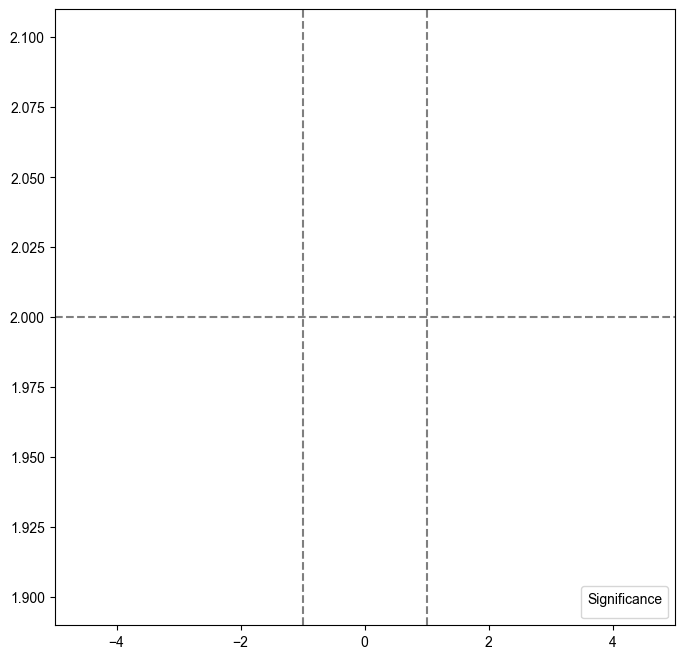

In [28]:
fig = plot_volcano(diff2,xlim=(-5,5))

In [23]:
purity_map

{'C3L-07287_T': 'Sufficient Purity',
 'C3L-11156_T': 'Sufficient Purity',
 'C3L-09494_T': 'Sufficient Purity',
 'CHTN-49141_T': 'Sufficient Purity',
 'C3L-11095_T': 'Sufficient Purity',
 'C3L-06504_T': 'Sufficient Purity',
 'C3L-07473_T': 'Sufficient Purity',
 'C3L-08293_T': 'Sufficient Purity',
 'C3L-09382_T': 'Sufficient Purity',
 'C3L-09691_T': 'Sufficient Purity',
 'C3L-09757_T': 'Sufficient Purity',
 'C3L-09801_T': 'Sufficient Purity',
 'C3L-09990_T': 'Sufficient Purity',
 'C3N-08476_T': 'Sufficient Purity',
 'C3N-08532_T': 'Sufficient Purity',
 'C3N-08879_T': 'Sufficient Purity',
 'C3N-08880_T': 'Sufficient Purity',
 'C3N-08949_T': 'Sufficient Purity',
 'C3N-08878_T': 'Sufficient Purity',
 'C3L-10486_T': 'Sufficient Purity',
 'C3L-06183_T': 'Sufficient Purity',
 'C3L-09383_T': 'Sufficient Purity',
 'C3L-06743_T': 'Sufficient Purity',
 'C3L-07871_T': 'Sufficient Purity',
 'C3L-08290_T': 'Sufficient Purity',
 'C3L-09797_T': 'Sufficient Purity',
 'C3L-10005_T': 'Sufficient Purity',
